# Detecting the anomalous activity of a ship’s engine

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-white')

from sklearn.preprocessing import StandardScaler
from scipy.stats import shapiro
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

# Import Data

In [2]:
# URL to import data set from GitHub.
url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv'

df = pd.read_csv(url)

# Exploratory Data Analysis

In [3]:
df.sample(10)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
4744,591,4.056983,6.477089,1.541876,77.690082,75.383577
11045,447,4.900773,7.183559,3.213953,77.120352,67.112524
9675,1091,4.931282,5.937141,1.438728,78.535319,83.444294
8892,447,3.358820,7.468399,1.043137,75.581169,66.057382
9736,478,5.423971,7.508909,2.557160,76.922122,71.686741
11916,1036,2.047411,5.922681,4.185108,74.949858,81.704364
16964,482,2.655286,14.839647,1.300826,77.667689,91.170024
1397,559,2.907897,10.115875,2.188321,77.506111,83.963104
17962,627,2.572679,9.261762,3.417192,82.978201,85.907334
8305,532,4.084339,5.012967,0.995557,75.242972,75.040454


In [5]:
df.shape[0]

19535

Identify any missing data

In [ ]:
df.isnull().sum()

,0
Engine rpm,0
Lub oil pressure,0
Fuel pressure,0
Coolant pressure,0
lub oil temp,0
Coolant temp,0


Identify any duplicate row data

In [ ]:
duplicates = df.loc[df.duplicated()]
print(duplicates.shape[0])

0


Descriptive Statistics

In [ ]:
#View the mean, mode and 95-100 percentiles

percentiles = [0.95,1]

df.describe(percentiles = percentiles)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662
95%,1324.000000,5.058040,12.208475,4.438415,84.940778,88.612891
100%,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912


Understand distribution of data

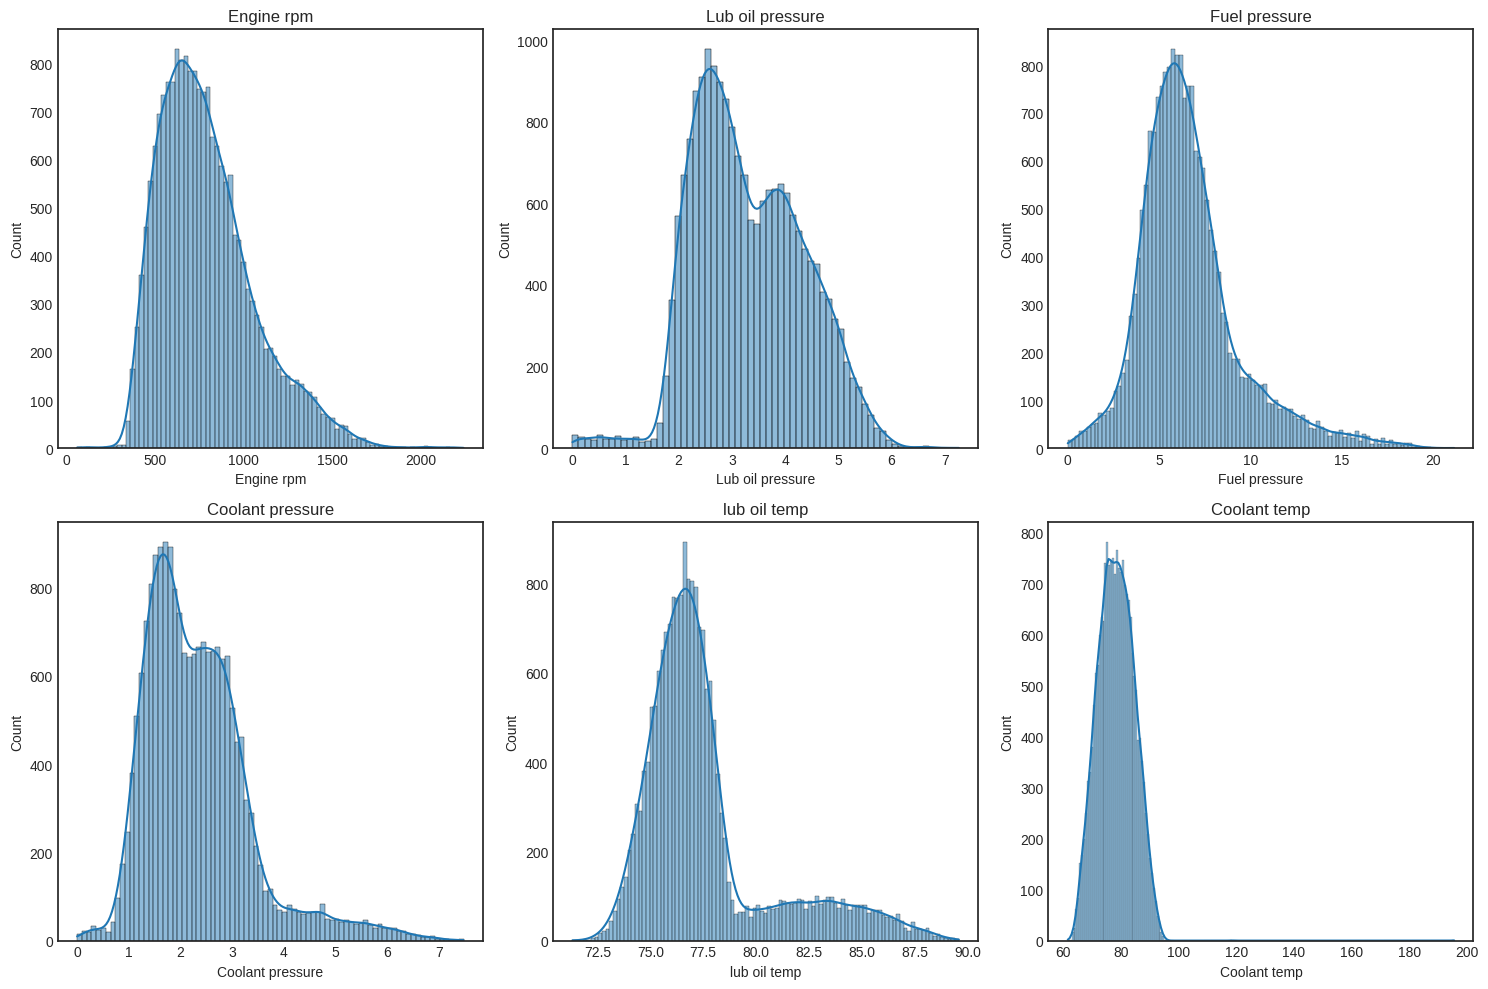

In [ ]:
# Create histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sns.histplot(df['Engine rpm'], ax=axes[0, 0], kde=True)
axes[0, 0].set_title('Engine rpm')

sns.histplot(df['Lub oil pressure'], ax=axes[0, 1], kde=True)
axes[0, 1].set_title('Lub oil pressure')

sns.histplot(df['Fuel pressure'], ax=axes[0, 2], kde=True)
axes[0, 2].set_title('Fuel pressure')

sns.histplot(df['Coolant pressure'], ax=axes[1, 0], kde=True)
axes[1, 0].set_title('Coolant pressure')

sns.histplot(df['lub oil temp'], ax=axes[1, 1], kde=True)
axes[1, 1].set_title('lub oil temp')

sns.histplot(df['Coolant temp'], ax=axes[1, 2], kde=True)
axes[1, 2].set_title('Coolant temp')

plt.tight_layout()
plt.show()

In [ ]:
# Perform the Shapiro–Wilk test.
alpha = 0.05

for column in df.columns:
  _, p = shapiro(df[column])

  if p > alpha:
    print(f'{column} data is normally distributed')
  else:
    print(f'{column} data is not normally distributed')

Engine rpm data is not normally distributed
Lub oil pressure data is not normally distributed
Fuel pressure data is not normally distributed
Coolant pressure data is not normally distributed
lub oil temp data is not normally distributed
Coolant temp data is not normally distributed


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 19535.
  res = hypotest_fun_out(*samples, **kwds)


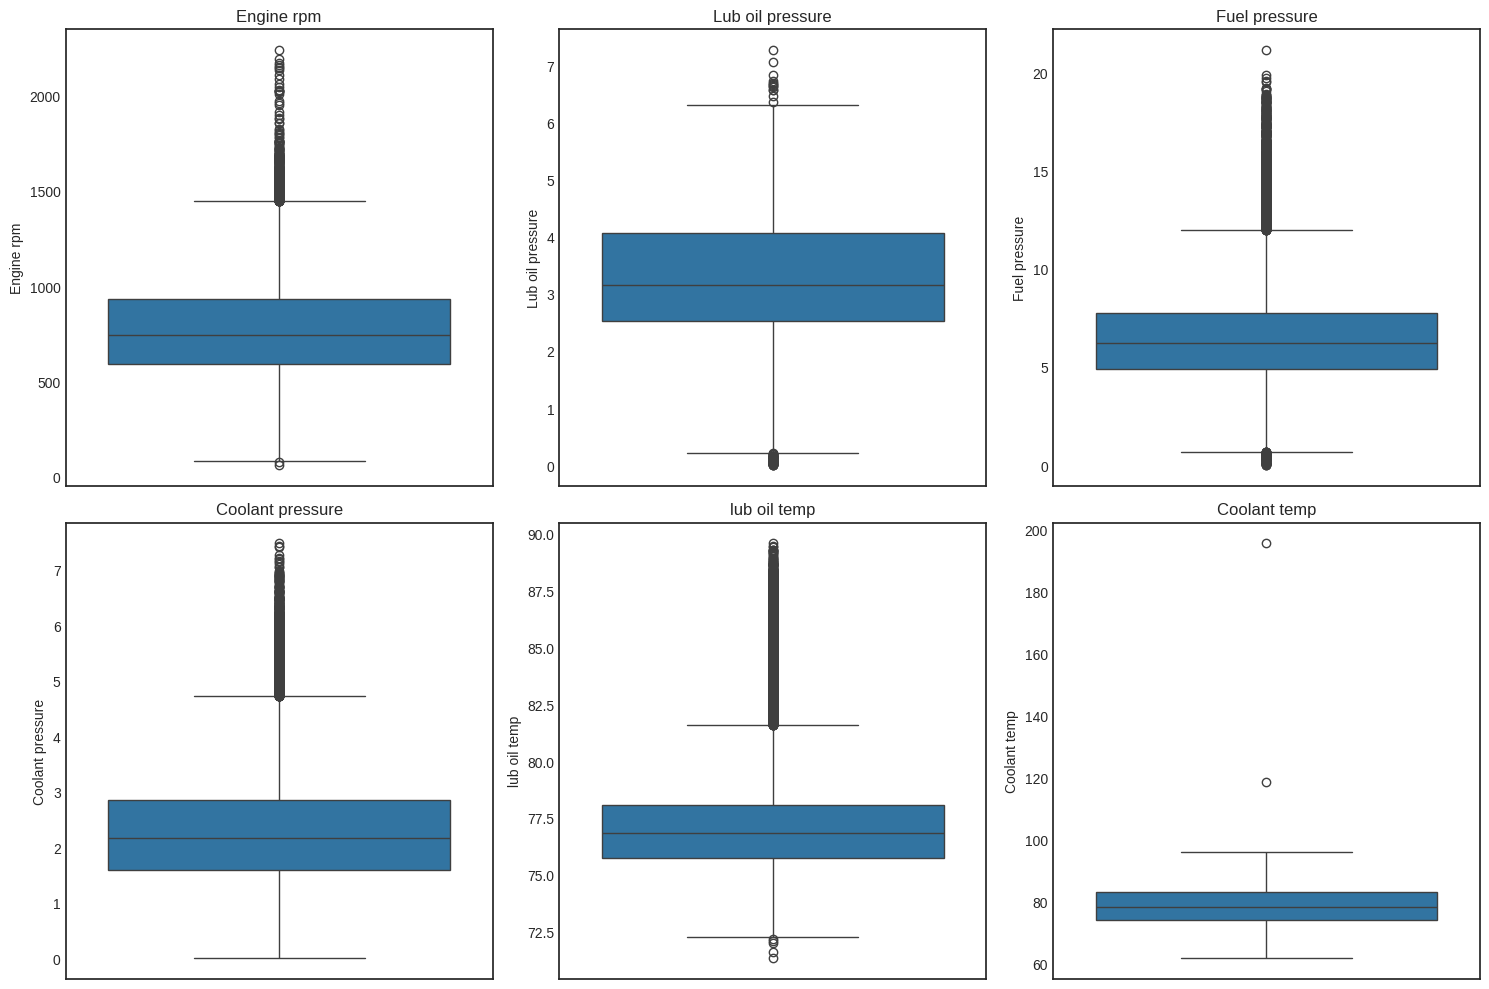

In [ ]:
#Create box plots

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sns.boxplot(df['Engine rpm'], ax=axes[0, 0])
axes[0, 0].set_title('Engine rpm')

sns.boxplot(df['Lub oil pressure'], ax=axes[0, 1])
axes[0, 1].set_title('Lub oil pressure')

sns.boxplot(df['Fuel pressure'], ax=axes[0, 2])
axes[0, 2].set_title('Fuel pressure')

sns.boxplot(df['Coolant pressure'], ax=axes[1, 0])
axes[1, 0].set_title('Coolant pressure')

sns.boxplot(df['lub oil temp'], ax=axes[1, 1])
axes[1, 1].set_title('lub oil temp')

sns.boxplot(df['Coolant temp'], ax=axes[1, 2])
axes[1, 2].set_title('Coolant temp')

plt.tight_layout()
plt.show()

# Use IQR to identify outliers

In [ ]:
df_IQR = df.copy()
id_columns = []

#Identify outlier features
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    new_col = col + "_outlier"
    id_columns.append(new_col)

    df_IQR[new_col] = (df[col] < lower) | (df[col] > upper)

#Create count column
df_IQR['Number of feature outliers'] = df_IQR[id_columns].sum(axis=1)


In [ ]:
#Display the columns flagging if a feature is an outlier based on IQR calculations

print(df_IQR[id_columns].head(10))

   Engine rpm_outlier  Lub oil pressure_outlier  Fuel pressure_outlier  \
0               False                     False                  False   
1               False                     False                  False   
2               False                     False                  False   
3               False                     False                  False   
4               False                     False                  False   
5               False                     False                  False   
6               False                     False                   True   
7               False                     False                   True   
8               False                     False                  False   
9               False                     False                   True   

   Coolant pressure_outlier  lub oil temp_outlier  Coolant temp_outlier  
0                     False                 False                 False  
1                      True          

In [ ]:
def identify_sample_outliers_IQR(benchmark):
  true_mask = df_IQR['Number of feature outliers'] >= benchmark
  return true_mask.sum()

In [ ]:
#Run model to identify samples with two + outlier features
benchmark = 2
n_sample_outliers = identify_sample_outliers_IQR(benchmark)

print(f"Original records: {len(df_IQR)}")
print(f"Records with {benchmark} or more feature outliers: {n_sample_outliers}")

Original records: 19535
Records with 2 or more feature outliers: 422


In [ ]:
#Identify the number of outlier features that results in the number of outliers being in the 1-5% range

best_n_features = 0
best_n_pct = 0

for i in range(1, len(id_columns)+1):
  benchmark = i
  n_sample_outliers = identify_sample_outliers_IQR(benchmark)
  pct_outliers = n_sample_outliers / len(df_IQR)

  print(f"A benchmark of {benchmark} features or greater, results in {pct_outliers:.2%} of samples being classified as outliers")

# Find best model parameters - defined as % of samples id'ed as anomalies closest to the mid-point of 1-5%
  if i == 1:
    best_n_features = i
    best_n_pct = pct_outliers
  elif abs(pct_outliers-0.03) < abs(best_n_pct-0.03):
      best_n_features = i
      best_n_pct = pct_outliers
  else:
    continue

print(f"\nThe best number of features is {best_n_features}")


A benchmark of 1 features or greater, results in 23.73% of samples being classified as outliers
A benchmark of 2 features or greater, results in 2.16% of samples being classified as outliers
A benchmark of 3 features or greater, results in 0.06% of samples being classified as outliers
A benchmark of 4 features or greater, results in 0.00% of samples being classified as outliers
A benchmark of 5 features or greater, results in 0.00% of samples being classified as outliers
A benchmark of 6 features or greater, results in 0.00% of samples being classified as outliers

The best number of features is 2


In [ ]:
#Store the row ids for comparison with the results from other models

df_IQR_identified_outliers = df[df_IQR['Number of feature outliers'] >= best_n_features]
IQR_set = set(df_IQR_identified_outliers.index)


In [ ]:
print(len(IQR_set))

422


**Thoughts and Reflections on using IQR**

Given that the data is not normally distributed, a $z$ score test would be an inappropriate method to identify outliers. The IQR method is an appropriate alternative.

It is easy to understand, allowing it to be readily explained to stakeholders. It also effectively flags records that are exceptionally large (or small) in a single, isolated dimension. In this exercise, setting a benchmark for treating a case as anomalous if 2+ of its features are outliers effectively identifies around 2% of the records as anomalies.

However, setting a benchmark requiring $n$ features to be outliers appears arbitrary, would miss anomalies that are massive in $<n$ features. It also does not account for interactions between features. For example, features A and B may not be outliers, but the interaction between them may be an indicator of an anomaly.

# Perform anomaly detection with ML models

Scale Features

In [ ]:
#Scale features
scaler = StandardScaler().set_output(transform="pandas") #Pandas parameter retains index
df_scaled = scaler.fit_transform(df)


In [ ]:
#Create reusable function for visualisation

def visualise(model, hp_one_value, hp_two_value, normal_points, anomaly_points, title, pct_anomolies):

  if model == 'OneClassSVM':
    hp_one_name = 'Gamma'
    hp_two_name = 'Nu'
  elif model == 'IsolationForest':
    hp_one_name = 'N_estimators'
    hp_two_name = 'Contamination'

  plt.clf()
  plt.figure(figsize=(10, 8))

  # Plot normal points (in blue)
  plt.scatter(
    normal_points[:, 0],
    normal_points[:, 1],
    c='skyblue',
    marker='o',
    s=50,
    label=f'Normal ({len(normal_points)} points)'
  )

  # Plot anomaly points (in red)
  plt.scatter(
    anomaly_points[:, 0],
    anomaly_points[:, 1],
    c='red',
    marker='x',
    s=100,
    label=f'Anomaly ({len(anomaly_points)} points)'
  )

  # Customize the plot
  plt.title(f'{title}\n{hp_one_name}: {hp_one_value}\n{hp_two_name}: {hp_two_value}\n % of Anomalies: {pct_anomolies:.2%}')
  plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
  plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
  plt.legend()
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.show()

In [ ]:
#Create PCA space
pca = PCA(n_components=2)
X_pca_scaled = pca.fit_transform(df_scaled)

In [ ]:
total_records = df.shape[0]
print(total_records)

19535


One Class Support Vector Machine

<Figure size 640x480 with 0 Axes>

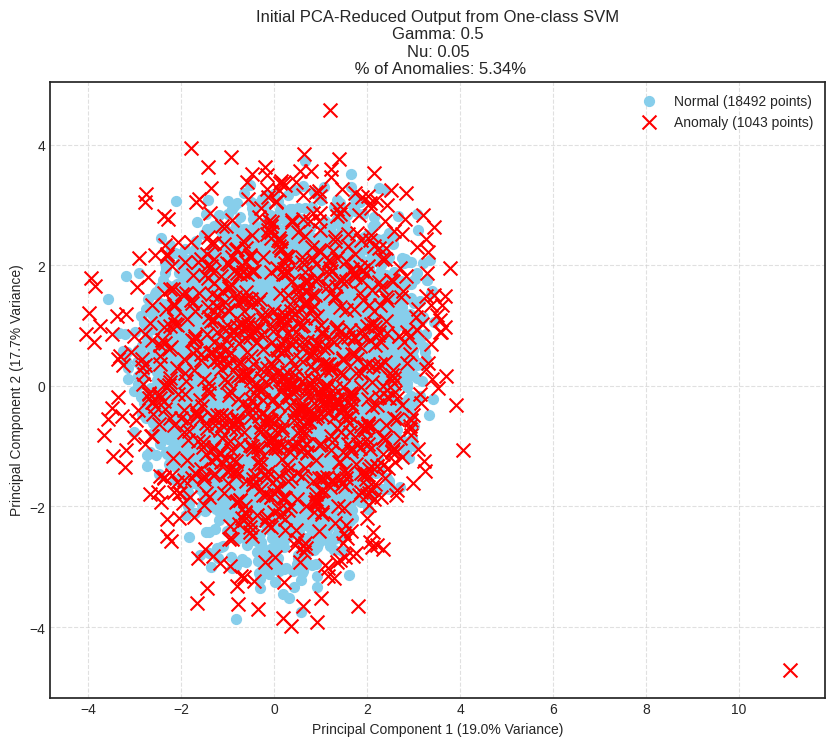

In [ ]:
#Carry out initial id of anomalies and visualise

gamma=0.5
nu=0.05
model_name = 'OneClassSVM'

model = OneClassSVM(kernel='rbf', gamma=gamma, nu=nu)
model.fit(df_scaled)

anomaly_id = model.predict(df_scaled)

# Plot the normal (1) and outlier (-1) points in the 2D PCA space
normal_points = X_pca_scaled[anomaly_id == 1]
anomaly_points = X_pca_scaled[anomaly_id == -1]

pct_anomalies = (len(anomaly_points) / total_records)

visualise(model_name, gamma, nu, normal_points, anomaly_points, 'Initial PCA-Reduced Output from One-class SVM', pct_anomalies)



In [ ]:
# Adjust model settings for One-class SVM to obtain the expected range
# of outliers where the target is defined as the mid-point of
# the desired 1-5% range

gamma_candidates = np.arange(0.1, 0.9, 0.1)
nu_candidates = np.arange(0.01, 0.11, 0.01)

best_nu = None
best_gamma = None
best_pct = float('inf')

target_percent_midpoint = 0.03 # Midpoint of the 1-5% target range

for nu in nu_candidates:
    for gamma in gamma_candidates:
      # Initialize and train the model
      model = OneClassSVM(nu=nu, kernel='rbf', gamma=gamma)
      model.fit(df_scaled)

      # Predict the results (-1 for anomaly, 1 for normal)
      anomaly_id = model.predict(df_scaled)

      # Calculate the actual anomaly percentage
      anomaly_count = np.sum(anomaly_id == -1)
      anomaly_pct = (anomaly_count / total_records)

      #Find 'best' - defined as % achieved closest to the mid-point of 1-5%
      # Update best_pct if the current anomaly_pct is closer to the target midpoint

      if round(anomaly_pct, 4) == target_percent_midpoint: #Target has been met
        best_gamma = gamma
        best_nu = nu
        best_pct = anomaly_pct
        print(f"Current best: nu={nu:.2f}, gamma={gamma:.1f}, % anomalies={anomaly_pct:.2%}, abs anomalies={anomaly_count}")
        break
      elif abs(anomaly_pct - target_percent_midpoint) < abs(best_pct - target_percent_midpoint):
        best_gamma = gamma
        best_nu = nu
        best_pct = anomaly_pct
        print(f"Current best: nu={nu:.2f}, gamma={gamma:.1f}, % anomalies={anomaly_pct:.2%}, abs. anomalies={anomaly_count}")

    if round(anomaly_pct, 4) == target_percent_midpoint: #Target has been met
      break

print(f"\nThe best nu is {best_nu}")
print(f"The best gamma is {best_gamma}")
print(f"These settings identify anomalies in {best_pct:.2%} of the samples")

Current best: nu=0.01, gamma=0.1, % anomalies=0.97%, abs. anomalies=189
Current best: nu=0.01, gamma=0.2, % anomalies=1.03%, abs. anomalies=202
Current best: nu=0.01, gamma=0.3, % anomalies=1.41%, abs. anomalies=275
Current best: nu=0.01, gamma=0.4, % anomalies=2.22%, abs. anomalies=434
Current best: nu=0.01, gamma=0.5, % anomalies=3.13%, abs. anomalies=611
Current best: nu=0.03, gamma=0.1, % anomalies=3.00%, abs anomalies=586

The best nu is 0.03
The best gamma is 0.1
These settings identify anomalies in 3.00% of the samples


<Figure size 640x480 with 0 Axes>

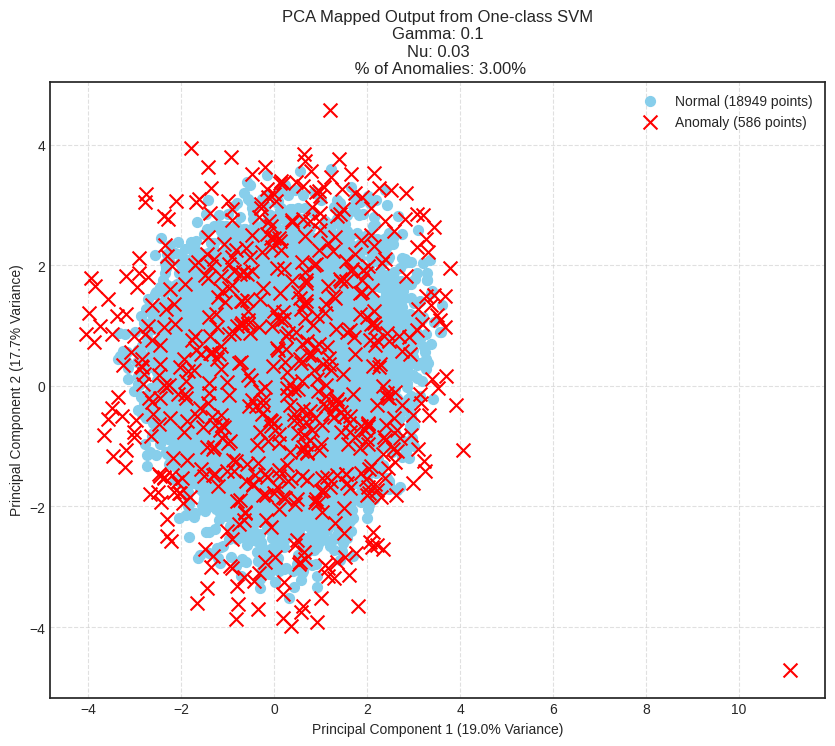

In [ ]:
#Run the model again with the 'best' parameters

best_model = OneClassSVM(nu=best_nu, kernel='rbf', gamma=best_gamma)
best_model.fit(df_scaled)

# Predict the results (-1 for anomaly, 1 for normal)
best_anomaly_id = best_model.predict(df_scaled)

#Visualise the results in PCA space

# Separate the normal (1) and outlier (-1) points in the 2D PCA space
normal_points = X_pca_scaled[best_anomaly_id == 1]
anomaly_points = X_pca_scaled[best_anomaly_id == -1]

best_anomaly_count = np.sum(best_anomaly_id == -1)
best_anomaly_pct = (best_anomaly_count / total_records)

model_name = 'OneClassSVM'

visualise(model_name, best_gamma, best_nu, normal_points, anomaly_points, 'PCA Mapped Output from One-class SVM', best_anomaly_pct)

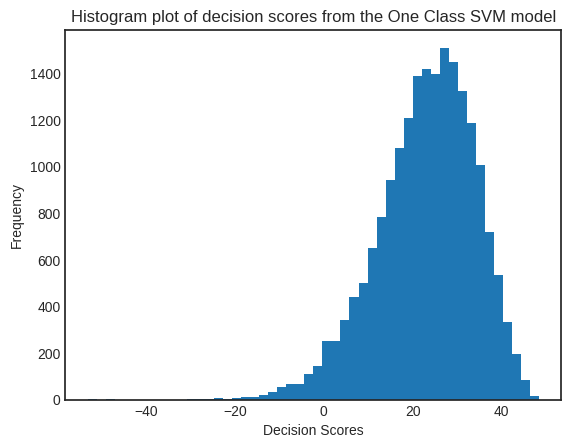

In [ ]:
#Show decision scores
ocsvm_scores = best_model.decision_function(df_scaled)

plt.hist(ocsvm_scores, bins=50)

plt.xlabel('Decision Scores')
plt.ylabel('Frequency')
plt.title('Histogram plot of decision scores from the One Class SVM model')
plt.show()

In [ ]:
#Store the results from the one-class SVM model when run with the 'best' parameters

is_anomaly = (best_anomaly_id == -1)
anomaly_indexes = df.index[is_anomaly]

SVM_set = set(anomaly_indexes)

In [ ]:
#Compare with results from IQR

#Indexes found by both methods
common_anomalies = SVM_set.intersection(IQR_set)

#Indexes found by SVM but missed by IQR
svm_only = SVM_set.difference(IQR_set)

#Indexes found by IQR but missed by SVM
iqr_only = IQR_set.difference(SVM_set)


print(f"Total IQR Anomalies: {len(IQR_set)}")
print(f"Total SVM Anomalies: {len(SVM_set)}")
print(f"Consensus: {len(common_anomalies)}")
print(f"SVM Unique: {len(svm_only)}")
print(f"IQR Unique: {len(iqr_only)}")

Total IQR Anomalies: 422
Total SVM Anomalies: 586
Consensus: 170
SVM Unique: 416
IQR Unique: 252


**Thoughts and Refelections on using One Class Support Vector Machine**

The parameters of Gamma = 0.1 and Nu = 0.03 identify 586 anomalies -  this is 3% of records in the dataset. (3% is the mid-point of the target 1-5% range.)

Interestingly, OCSVM - as a more sophisticated machine learning method - identified a large number of anomalies, 416 out of 586, or 71% of the OCSVM identified anomalies, that were not identified through the IQR approach.

The visualisation needs explaining, and would be difficult for stakeholders to grasp. Intuitively, you would expect a clear boundary - as in the Iris demo example - between the 'typical' cases and the identfied anomalies. However, because of the dimensionality reduction through PCA, the two categories over-lap on the plotted area. This is in part a consequence of the two PCAs, together, only accounting for 37% of variation in the dataset.

However, the decision scores show the long-tail of “more negative” scores, and a clear separation around 0, which is what you would expect.

# Isolation Forests (ISO)

In [ ]:
#In order to min. varaince, establish the convergance point around the estimator parameter
estimator_candidates = [20, 50, 80, 100, 150, 200, 300]
pct_contamination = 0.03 # Set contamination parameter to 0.03 - the midpoint between 1% and 5%
n_trials = 10

convergence_data = []

for estimator in estimator_candidates:
  trial_scores = []
  for n in np.arange(1, n_trials+1):
    iso_forest = IsolationForest(n_estimators=estimator, contamination=pct_contamination, random_state = 42)
    iso_forest.fit(df)

    #Get raw anomaly scores - in this instance, path length
    scores = iso_forest.decision_function(df)
    trial_scores.append(np.mean(scores))

    # Calculate the standard deviation of the mean scores across all trials
    stdev_of_mean_score = np.std(trial_scores)

    convergence_data.append([estimator, stdev_of_mean_score])

best_estimator_result = min(convergence_data, key=lambda x: x[1])
print(f"The best estimator is {best_estimator_result[0]} with a standard deviation of {best_estimator_result[1]:.4f}")


The best estimator is 20 with a standard deviation of 0.0000


In [ ]:
# Re-initialize Isolation Forest with the best_n_estimators and the target contamination

iso_forest = IsolationForest(n_estimators=best_estimator_result[0], contamination=pct_contamination, random_state=42) # Using a fixed random_state for reproducibility
iso_forest.fit(df)
anomaly_id = iso_forest.predict(df)

<Figure size 640x480 with 0 Axes>

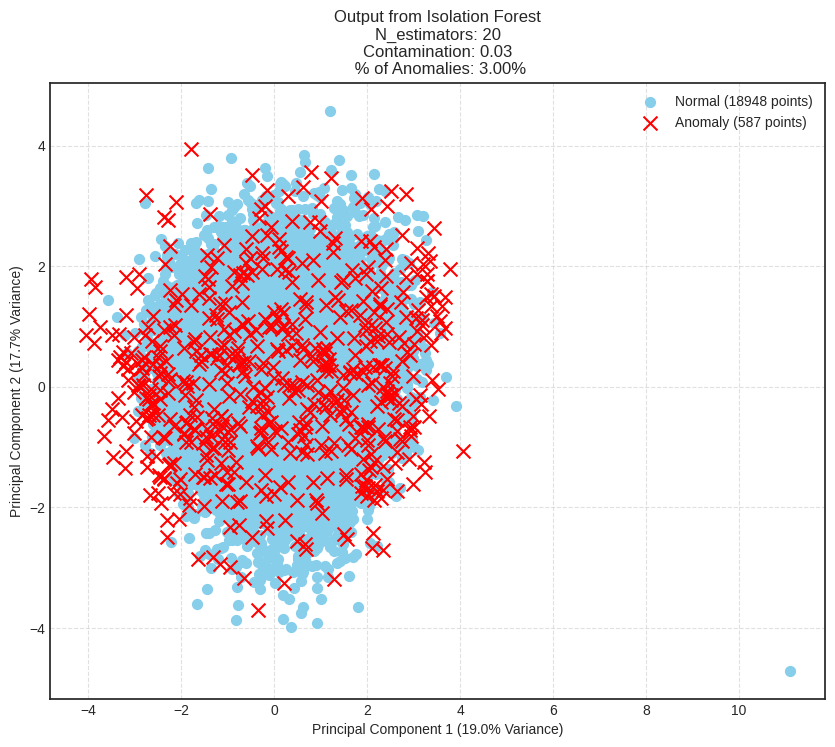

In [ ]:
#Visualise the results in PCA space

normal_points = X_pca_scaled[anomaly_id == 1]
anomaly_points = X_pca_scaled[anomaly_id == -1]

pct_anomalies = (len(anomaly_points) / total_records)
model_name = 'IsolationForest'

# Pass best_n_estimators instead of n_estimators
visualise(model_name, best_estimator_result[0], pct_contamination, normal_points, anomaly_points, 'Output from Isolation Forest', pct_anomalies)

In [ ]:
#Investigate point on PC1 c.11 which looks a clear outlier, but is categorised as normal

#Identify the index of the furthest point on the right (Max PC1)
extreme_idx = np.argmax(X_pca_scaled[:, 0])

#Extract values for the outlier and the dataset averages
features = df.columns
extreme_values = df.iloc[extreme_idx].values
averages = df.mean().values

#Calculate the difference (Numerical)
diff = extreme_values - averages
perc_diff = (diff / averages) * 100

comparison_df = pd.DataFrame({
    'Feature': features,
    'Extreme Point Value': extreme_values,
    'Dataset Average': averages,
    'Difference (%)': perc_diff
})

print(comparison_df.round(2).to_string(index=False))

#Get scores
ocsvm_score = ocsvm_scores[extreme_idx]
iso_score = iso_forest.decision_function(df.iloc[[extreme_idx]])[0]

print(f"\nOne-Class SVM Score: {ocsvm_score:.4f}")
print(f"Isolation Forest Score: {iso_score:.4f}")



         Feature  Extreme Point Value  Dataset Average  Difference (%)
      Engine rpm               455.00           791.24          -42.50
Lub oil pressure                 2.01             3.30          -39.14
   Fuel pressure                 7.81             6.66           17.29
Coolant pressure                 1.62             2.34          -30.65
    lub oil temp                76.52            77.64           -1.45
    Coolant temp               195.53            78.43          149.31

One-Class SVM Score: -53.0375
Isolation Forest Score: 0.0207


In [ ]:
#Store the overall results to enable comparison with One Class SVM

anomaly_indexes = df.index[anomaly_id == -1]

iso_forest_set = set(anomaly_indexes)

In [ ]:
#Carry out comparison with One Class SVM

#Indexes found by both methods
common_anomalies = iso_forest_set.intersection(SVM_set)

#Indexes found by iso_forest but missed by svm
iso_only = iso_forest_set.difference(SVM_set)

#Indexes found by SVM but missed by SVM
SVM_only = SVM_set.difference(iso_forest_set)


print(f"Total ISO Forest Anomalies: {len(iso_forest_set)}")
print(f"Total SVM Anomalies: {len(SVM_set)}")
print(f"Consenus: {len(common_anomalies)}")
print(f"ISO Unique: {len(iso_only)}")
print(f"SVM Unique: {len(SVM_only)}")

Total ISO Forest Anomalies: 587
Total SVM Anomalies: 586
Consenus: 306
ISO Unique: 281
SVM Unique: 280


**Thoughts and Refelections on using Isolation Forest (ISO)**

We are now seeing a good overlap in the anomalies identified by the OCSVM and ISO methods - 306 records, or 1.57% of the total records. For a business, this could be reasonably treated as the priority anomalies to investigate. This reflects the advantages of each method.
OCSVM is better at capturing anomalies related to the shape and density of the data, while ISO is better at finding the globally distant points that are readily isolatable.

The presence of the clear outlier on PC One highlights the difference between the two methods - it is scored as an outlier on One Class SVM, but not in ISO. Loking at the feature values, One Class SVM seems able to identify the combination of the extreme Coolant temp vs. Engine rpm as outside of the boundary plane. ISO, in making a series of cuts, may take a longer path to isolate on these two feature values.

Given the availability of the contamination parameter, it was easy to identify anomalies in the 1-5% range when using ISO. However, we iteratively identified the 'best' estimator paramater (or, the parameter that specifies the number of trees in the forest) by looking for the value that minimised variation in path lengths needed to identify the anomalies.

### Reference:
Devabrat, M., 2022. Predictive Maintenance on Ship's Main Engine using AI. Available at: https://dx.doi.org/10.21227/g3za-v415. [Accessed 5 March 2024]